<a href="https://colab.research.google.com/github/aniketbhaumik/StockPricePredictions/blob/main/MCS_StockPrice_LSTM_7_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os
import torch.nn.functional as F
from torch.nn.utils import rnn
from sklearn.preprocessing import MinMaxScaler

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# parameters

n_simulations = 10000  # Number of simulations
n_steps = 252  # Number of time steps (daily)
sigma_A = 0.02  # Volatility for Stock A
T = 1  # Time horizon (1 year)
dt = T / n_steps  # Time step size

### Generating Data

In [ ]:
# Function to simulate stock prices over time
def simulate_stock_paths(sigma, n_simulations, n_steps=252, dt=1/252):

  """
  Simulates stock prices over time using a simplified Geometric Brownian Motion (GBM) model.
  """
  # Initialize stock prices randomly in the range [50, 100]
  S0 = np.random.uniform(50, 100, n_simulations)
  stock_paths = np.zeros((n_simulations, n_steps))
  stock_paths[:, 0] = S0

  for t in range(1, n_steps):
    random_shock = np.random.normal(0, 2 * sigma, n_simulations)
    stock_paths[:, t] = stock_paths[:, t - 1] * np.exp(random_shock)

    # Z_A = np.random.normal(0, 2, n_simulations)
    # stock_paths[:, t] = stock_paths[:, t - 1] * np.exp((0.05 - 0.5 * sigma_A**2) * dt + sigma_A * np.sqrt(dt) * Z_A)

  return stock_paths


simulated_paths_A = simulate_stock_paths(sigma_A, n_simulations, n_steps)

### loading data

In [ ]:
# to load previously simulated data
from google.colab import files
uploaded = files.upload()  # This opens a file picker to upload

simulated_paths_A = np.load("simulated_paths_A.npy")

In [ ]:
# Convert to DataFrame
df_A = pd.DataFrame(simulated_paths_A)
df_A.head()

,0,1,2,3,4,5,6,7,8,9,...,242,243,244,245,246,247,248,249,250,251
0,50.702621,55.863776,56.663906,59.406119,60.330157,62.636201,59.611511,62.086376,63.911108,70.395910,...,136.583344,136.466342,138.802662,141.024253,137.435889,138.038317,144.320194,153.290674,156.429889,163.840639
1,94.071460,93.787580,91.133708,91.886515,89.288767,85.360440,84.455840,87.683666,90.659551,85.485415,...,37.986939,39.154465,40.371130,43.270115,43.744026,45.284100,48.304437,50.273116,48.915397,46.440308
2,92.346839,91.284867,90.371534,89.996349,93.045207,87.484106,85.213197,80.886902,85.784003,82.291000,...,64.434849,66.070718,66.470187,67.253611,67.265152,68.374469,65.409312,68.807863,71.428295,73.943168
3,81.142532,79.660914,81.723611,85.091516,81.702305,92.171903,86.082139,90.409118,92.490161,89.902261,...,147.990568,147.104849,147.934121,160.498179,159.653600,161.597967,161.329970,159.139292,153.802357,151.547500
4,58.662895,59.588900,63.252112,63.130662,61.970300,60.138631,58.961516,59.466278,58.050770,56.701769,...,51.335167,53.009278,51.858120,55.206263,54.657657,53.321250,52.803436,52.953456,55.482964,52.426635


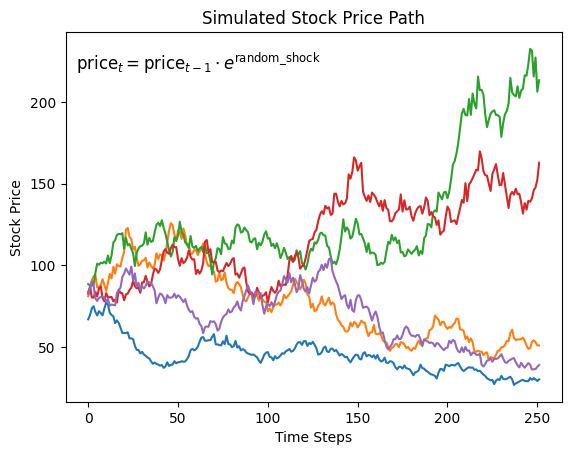

In [ ]:
# to plot the simulated price paths

plt.figure()

simulation_index1 = [np.random.randint(0, n_simulations) for _ in range(5)]
actual_prices = np.zeros((n_simulations, n_steps))

for ind in simulation_index1:
    actual_prices[ind] = simulated_paths_A[ind]
    plt.plot(actual_prices[ind])

plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.title("Simulated Stock Price Path")
plt.gca().text(0.02, 0.95,
    r'$\mathrm{price}_t = \mathrm{price}_{t-1} \cdot e^{\mathrm{random\_shock}}$',
    transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()

### scaling data

In [ ]:
# scaled data

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_simulations_A = scaler.fit_transform(simulated_paths_A)
scaled_simulations_A

array([[-0.97214214, -0.69829512, -0.64989417, ..., -0.56256322,
        -0.54712089, -0.5455051 ],
       [ 0.76306101,  0.40534638,  0.25477426, ..., -0.869645  ,
        -0.87125375, -0.88416547],
       [ 0.69405832,  0.33251355,  0.23477081, ..., -0.81439536,
        -0.80338225, -0.80482899],
       ...,
       [ 0.91747585,  0.57292442,  0.4321318 , ..., -0.83574287,
        -0.82673269, -0.82520188],
       [-0.70680117, -0.66022334, -0.69047896, ..., -0.91664236,
        -0.91750308, -0.9169583 ],
       [ 0.06950065, -0.15843288, -0.21796882, ..., -0.83676471,
        -0.83328761, -0.83050847]])

### prepare sequences

In [ ]:
# Function to prepare sequences from Monte Carlo Simulations
def prepare_data(stock_paths, seq_length=7):
  sequences, targets = [], []
  for path in stock_paths:
    for i in range(len(path) - seq_length):
      sequences.append(path[i:i + seq_length])
      targets.append(path[i+1: i+seq_length+1])
      # targets.append(path[i+seq_length])
  return np.array(sequences), np.array(targets)

In [ ]:
# Prepare dataset
seq_length = 7
X, y = prepare_data(scaled_simulations_A, seq_length)
X.shape, y.shape

((2450000, 7), (2450000, 7))

### Train-Test split

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
# train test split
split_index = int(0.7 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1715000, 7), (735000, 7), (1715000, 7), (735000, 7))

In [ ]:
# reshaping the data to fit the input tensor shape
X_train = X_train.reshape((-1, seq_length, 1))
X_test = X_test.reshape((-1, seq_length, 1))
# y_train = y_train.reshape(-1, 1)
# y_test = y_test.reshape(-1, 1)
y_train = y_train.reshape((-1, seq_length, 1))
y_test = y_test.reshape((-1, seq_length, 1))
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1715000, 7, 1), (735000, 7, 1), (1715000, 7, 1), (735000, 7, 1))

In [ ]:
# converting the train and test data into tensors
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([1715000, 7, 1]),
 torch.Size([735000, 7, 1]),
 torch.Size([1715000, 7, 1]),
 torch.Size([735000, 7, 1]))

### creating train, validation and test dataset for Model

In [ ]:
from torch.utils.data import Dataset, random_split, DataLoader

In [ ]:
class StockPriceDataset(Dataset):
  """
  Custom Dataset for Stock Price Forecasting
  """
  def __init__(self, X, y):
    self.X= X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [ ]:
full_train_dataset = StockPriceDataset(X_train, y_train)
# Split train into train and val (85% train, 15% val)
len_ = len(full_train_dataset)
train_size = int(0.85 * len_)
val_size = len_ - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Create test dataset
test_dataset = StockPriceDataset(X_test, y_test)

# create dataloader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### model

In [ ]:
class StockPriceLSTM(nn.Module):
  """
  LSTM Model for Stock Price Forecasting
  """
  def __init__(self, input_size=1, hidden_size=10, n_layers=1, output_size=1):
    super().__init__()
    self.hidden_size = hidden_size
    self.n_layers = n_layers
    self.lstm = nn.LSTM(input_size,
                       hidden_size,
                       n_layers,
                      #  dropout=0.2,
                       batch_first=True)
    # self.dropout = nn.Dropout(0.2)
    self.fc = nn.Linear(hidden_size, output_size)

  def init_hidden_state(self, h):
      return nn.init.xavier_uniform_(h, gain=nn.init.calculate_gain('relu'))

  def forward(self, x):
    batch_size = x.size(0)
    h0 = torch.zeros(self.n_layers, batch_size, self.hidden_size).requires_grad_()
    c0 = torch.zeros(self.n_layers, batch_size, self.hidden_size).requires_grad_()
    h0 = self.init_hidden_state(h0).to(device)
    c0 = self.init_hidden_state(c0).to(device)
    #print(f"X:{x.shape}")
    #lens = torch.tensor([seq.shape[1] for seq in x])
    #x = rnn.pack_padded_sequence(x, lens, batch_first=True, enforce_sorted=False)
    out, _ = self.lstm(x, (h0,c0)) # out.shape = (batch_size, seq_len,hidden_size)
    #print(out.shape)
    #out, _ = rnn.pad_packed_sequence(out, batch_first=True)
    #out = self.fc(out[:,-1,:])
    #print(out.shape)
    # out = self.dropout(out)
    out = self.fc(out)
    return out

In [ ]:
# Model parameters
input_size = 1
hidden_size = 32
n_layers = 1
output_size = 1

### Training and Validation loop defination

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device='cpu'):
  """
  Train the model for one epoch
  """

  model.train()
  epoch_loss = []

  # Wrap train_loader with tqdm for progress bar
  pbar = tqdm(train_loader, desc="Training", leave=False)
  for X_batch, y_batch in pbar:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    #print(f"X:{X_batch.shape}, Y:{y_batch.shape}")
    optimizer.zero_grad()
    outputs = model(X_batch)
    #print(f"OUT:{outputs.shape}")
    loss = criterion(outputs, y_batch)
    # loss = Sloss(outputs, y_batch).mean()

    loss.backward()
    optimizer.step()

    epoch_loss.append(loss.item())

  return np.mean(epoch_loss)

def validate_one_epoch(model, val_loader, criterion, device='cpu'):
    """
    Validate the model for one epoch
    """
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            # loss = Sloss(outputs, labels).mean()
            val_loss += loss.item()
            # Optional: log to wandb
            # wandb.log({"val_loss": loss.item()})
    avg_val_loss = val_loss / len(val_loader)
    return avg_val_loss

### Training script

In [ ]:
# initialise model
model = StockPriceLSTM(input_size, hidden_size, n_layers, output_size).to(device)
model

StockPriceLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
# Define save directory and create it if it doesn't exist
save_dir = "models/Stock_price_LSTM"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "best_model.pth")

train_losses = []
val_losses = []
best_val_loss = float('inf')

# Training loop
num_epochs = 7


optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) #

# loss
criterion = nn.SmoothL1Loss()
# criterion = nn.MSELoss()


for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print(f"Saved new best model with val loss {best_val_loss:.6f}")

print(f"Final best model saved to {save_path}")


Epoch 1/7


Train Loss: 0.001160 | Val Loss: 0.000485
Saved new best model with val loss 0.000485

Epoch 2/7


Train Loss: 0.000483 | Val Loss: 0.000480
Saved new best model with val loss 0.000480

Epoch 3/7


Train Loss: 0.000478 | Val Loss: 0.000477
Saved new best model with val loss 0.000477

Epoch 4/7


Train Loss: 0.000473 | Val Loss: 0.000471
Saved new best model with val loss 0.000471

Epoch 5/7


Train Loss: 0.000470 | Val Loss: 0.000468
Saved new best model with val loss 0.000468

Epoch 6/7


Train Loss: 0.000469 | Val Loss: 0.000471

Epoch 7/7


Train Loss: 0.000469 | Val Loss: 0.000468
Final best model saved to models/Stock_price_LSTM/best_model.pth


In [ ]:
training_loss = np.array(train_losses).mean()
validation_loss = np.array(val_losses).mean()
print(f"Training Loss: {training_loss:.6f} | Validation Loss: {validation_loss:.6f}")

Training Loss: 0.000572 | Validation Loss: 0.000474


In [ ]:
# model = StockPriceLSTM(input_size, hidden_size, n_layers, output_size)
model.load_state_dict(torch.load('models/Stock_price_LSTM/best_model.pth'))

<All keys matched successfully>

### Performance

In [ ]:
val_losses_array = np.array(val_losses)
sqrt_val_losses = np.sqrt(val_losses_array)
performance = np.mean(sqrt_val_losses)
print(f"Performance: {performance:.6f}")

Performance: 0.022274


### loss curve

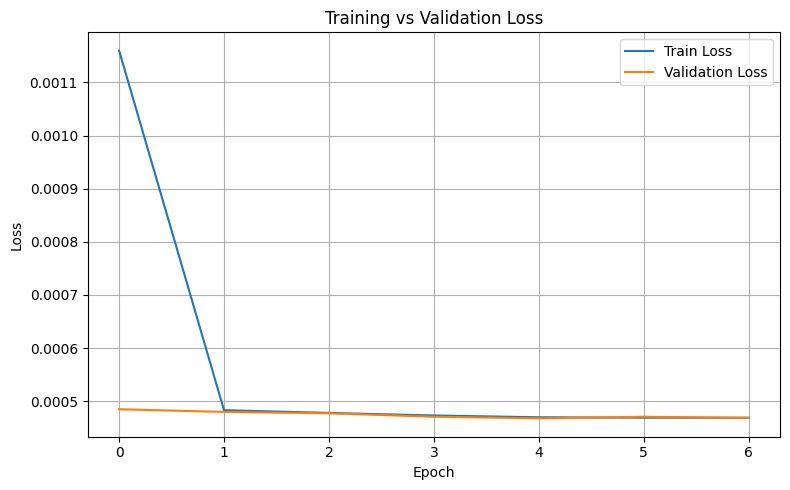

In [ ]:
# loss curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### model evaluation

In [ ]:
# model.eval()
# with torch.inference_mode():
#   y_pred_scaled = model(X_test.to(device))
#   test_loss = criterion(y_pred_scaled, y_test.to(device))
#   # test_loss = Sloss(y_pred_scaled, y_test.to(device)).mean()

# print(f"Test Loss: {test_loss:.6f}")


# when low on space use the below code

model.eval()
with torch.inference_mode():
  batch_size = 128  # Adjust as needed
  y_pred_scaled = []
  test_loss_total = 0  # Initialize total test loss
  for i in range(0, X_test.shape[0], batch_size):
    batch = X_test[i:i + batch_size].to(device)
    # Move prediction to device instead of CPU
    y_pred_scaled_batch = model(batch)
    y_pred_scaled.append(y_pred_scaled_batch)

    # Both tensors are now on the same device
    test_loss = criterion(y_pred_scaled_batch, y_test[i:i + batch_size].to(device))
    test_loss_total += test_loss.item()  # Accumulate loss

  y_pred_scaled = torch.cat(y_pred_scaled, dim=0)

# Calculate average test loss
avg_test_loss = test_loss_total / len(X_test)

print(f"Test Loss: {avg_test_loss:.6f}")

Test Loss: 0.000004


In [ ]:
# Move to CPU and convert to NumPy
y_pred = y_pred_scaled.cpu().numpy()
y_test_actual = y_test.cpu().numpy()

# Derive how many full simulations were used in the test set
samples_per_sim = n_steps - seq_length
num_test_samples = y_test.shape[0]
num_test_simulations = num_test_samples // samples_per_sim

# slice the last time step from each sequence
y_pred = y_pred[:, -1, :]
y_test_actual = y_test_actual[:, -1, :]

# Reshape predictions and targets to [num_simulations, sequence] for y =1x1
# y_pred_reshaped = y_pred[:num_test_simulations * samples_per_sim].reshape(num_test_simulations, -1)
# y_test_reshaped = y_test_actual[:num_test_simulations * samples_per_sim].reshape(num_test_simulations, -1)

# reshape predictions and targets
y_pred_reshaped = y_pred[:num_test_simulations * samples_per_sim].reshape(num_test_simulations, samples_per_sim, -1)
y_test_reshaped = y_test_actual[:num_test_simulations * samples_per_sim].reshape(num_test_simulations, samples_per_sim, -1)

# # Reconstruct full series by placing predictions after seq_length
# reconstructed_pred = np.zeros((num_test_simulations, n_steps))
# reconstructed_test = np.zeros((num_test_simulations, n_steps))

# reconstructed_pred[:, seq_length:] = y_pred_reshaped
# reconstructed_test[:, seq_length:] = y_test_reshaped

# foy y =10x1
reconstructed_pred = np.zeros((num_test_simulations, n_steps))
reconstructed_test = np.zeros((num_test_simulations, n_steps))

reconstructed_pred[:, seq_length:] = y_pred_reshaped[:, :, 0].reshape(num_test_simulations, -1)
reconstructed_test[:, seq_length:] = y_test_reshaped[:, :, 0].reshape(num_test_simulations, -1)

initial_inputs = X_test[::samples_per_sim, :, 0].cpu().numpy()
reconstructed_pred[:, :seq_length] = initial_inputs.reshape(-1, seq_length)
reconstructed_test[:, :seq_length] = initial_inputs.reshape(-1, seq_length)


# Inverse scale to original prices
y_pred_original_scale = scaler.inverse_transform(reconstructed_pred)
y_test_original_scale = scaler.inverse_transform(reconstructed_test)

### visualise after evaluating

In [ ]:
# Pick a random simulation index to visualize
simulation_index = np.random.randint(0, num_test_simulations)
actual_prices = y_test_original_scale[simulation_index]
predicted_prices = y_pred_original_scale[simulation_index]

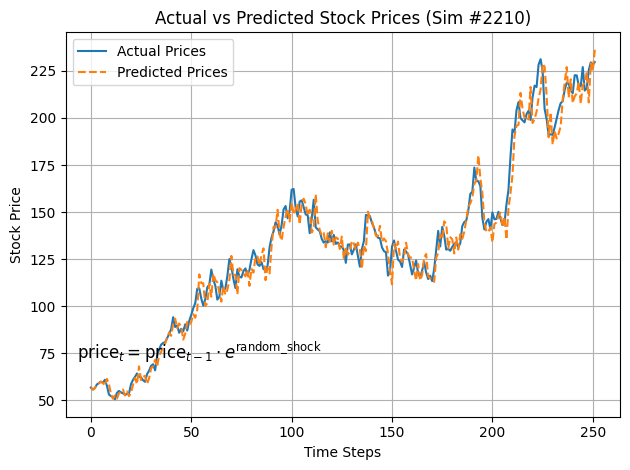

In [ ]:
# Plotting
# plt.figure(figsize=(10, 5))
plt.figure()
plt.plot(actual_prices, linestyle='-', label="Actual Prices")
plt.plot(predicted_prices, linestyle='--', label="Predicted Prices")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.title(f"Actual vs Predicted Stock Prices (Sim #{simulation_index})")
plt.gca().text(0.02, 0.20,
    r'$\mathrm{price}_t = \mathrm{price}_{t-1} \cdot e^{\mathrm{random\_shock}}$',
    transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Autoregressive

In [ ]:
samples_per_sim = n_steps - seq_length
num_test_simulations = y_test.shape[0] // samples_per_sim
X_init = X_test[::samples_per_sim]  # (num_simulations, seq_length, 1)

model.eval()
future_steps = n_steps - seq_length
generated_seq = X_init.clone().to(device)  # (simulations, seq_len, 1)
forecast_result = X_init.clone().to(device)  # to store initial + all predictions

with torch.no_grad():
    for _ in tqdm(range(future_steps), desc="Autoregressive Forecasting"):
        pred = model(generated_seq)  # shape: (batch, seq_len, 1)
        next_pred = pred[:, -1:, :]  # shape: (batch, 1, 1) — predicted value at next step

        # Slide window: drop first time step, append prediction
        generated_seq = torch.cat((generated_seq[:, 1:, :], next_pred), dim=1)

        # Accumulate prediction to final output
        forecast_result = torch.cat((forecast_result, next_pred), dim=1)

X_test_pred_full = forecast_result.squeeze(-1).cpu().numpy()  # shape: (num_simulations, n_steps)
print(X_test_pred_full.shape)
y_pred_autoreg = scaler.inverse_transform(X_test_pred_full)

Autoregressive Forecasting: 100%|██████████| 245/245 [00:00<00:00, 459.31it/s]

(3000, 252)


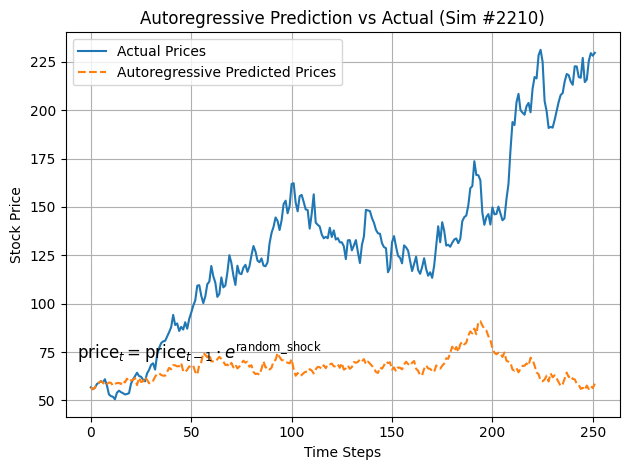

In [ ]:
# plot autoregressive prediction

# plt.figure(figsize=(10, 5))
plt.figure()
plt.plot(actual_prices, label="Actual Prices")
# plt.plot(actual_test_full[simulation_index], label="Actual Prices")
plt.plot(y_pred_autoreg[simulation_index], linestyle='--', label="Autoregressive Predicted Prices")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.title(f"Autoregressive Prediction vs Actual (Sim #{simulation_index})")
plt.gca().text(0.02, 0.20,
    r'$\mathrm{price}_t = \mathrm{price}_{t-1} \cdot e^{\mathrm{random\_shock}}$',
    transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true, axis=1)
    pred_diff = np.diff(y_pred, axis=1)
    direction_true = np.sign(true_diff)
    direction_pred = np.sign(pred_diff)
    # accuracy = np.mean(direction_true == direction_pred)
    accuracy = np.mean(true_diff*pred_diff>0)
    return accuracy

da = directional_accuracy(y_test_original_scale, y_pred_original_scale)
print(f"Directional Accuracy: {da * 100:.2f}%")

Directional Accuracy: 51.27%


### Evaluation metrics for normal prediction

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_original_scale.flatten(), y_pred_original_scale.flatten())
print(f"MAE: {mae:.4f}")

rmse = mean_squared_error(y_test_original_scale.flatten(), y_pred_original_scale.flatten())
rmse = np.sqrt(rmse)
print(f"RMSE: {rmse:.4f}")

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

mape = mean_absolute_percentage_error(y_test_original_scale.flatten(), y_pred_original_scale.flatten())
print(f"MAPE: {mape:.2f}%")

r2 = r2_score(y_test_original_scale.flatten(), y_pred_original_scale.flatten())
print(f"R² Score: {r2:.4f}")

MAE: 3.2791
RMSE: 4.7657
MAPE: 4.04%
R² Score: 0.9889


### evaluation metrics for autoregressive prediction

In [ ]:
mae_autoreg = mean_absolute_error(y_test_original_scale.flatten(), y_pred_autoreg.flatten())
r2_autoreg = r2_score(y_test_original_scale.flatten(), y_pred_autoreg.flatten())
mape_autoreg = mean_absolute_percentage_error(y_test_original_scale.flatten(), y_pred_autoreg.flatten())
da_autoreg = directional_accuracy(y_test_original_scale, y_pred_autoreg)

print(f"Autoregressive MAE: {mae_autoreg:.4f}")
print(f"Autoregressive R² Score: {r2_autoreg:.4f}")
print(f"Autoregressive MAPE: {mape_autoreg:.2f}%")
print(f"Autoregressive Directional Accuracy: {da_autoreg * 100:.2f}%")

Autoregressive MAE: 30.4929
Autoregressive R² Score: 0.0470
Autoregressive MAPE: 48.42%
Autoregressive Directional Accuracy: 51.26%


In [ ]:
results_LSTM_7 = {
    'model': 'LSTM',
    'seq_len': seq_length,
    'n_layers': n_layers,
    'hidden_size': hidden_size,
    'mae': mae,
    'rmse': rmse,
    'mape': mape,
    'r2': r2,
    'directional_accuracy': f'{da*100:.2f}%'
}
results_LSTM_7

{'model': 'LSTM',
 'seq_len': 7,
 'n_layers': 1,
 'hidden_size': 32,
 'mae': 3.2791395059263375,
 'rmse': np.float64(4.765651581719377),
 'mape': np.float64(4.043808356552826),
 'r2': 0.9889198659793499,
 'directional_accuracy': '51.27%'}

In [ ]:
results_LSTM_7_autoreg = {
    'model': 'LSTM_autoreg',
    'seq_len': seq_length,
    'n_layers': n_layers,
    'hidden_size': hidden_size,
    'mae': mae_autoreg,
    'rmse': rmse,
    'mape': mape_autoreg,
    'r2': r2_autoreg,
    'directional_accuracy': f'{da_autoreg*100:.2f}%'
}
results_LSTM_7_autoreg

{'model': 'LSTM_autoreg',
 'seq_len': 7,
 'n_layers': 1,
 'hidden_size': 32,
 'mae': 30.492861540890683,
 'rmse': np.float64(4.765651581719377),
 'mape': np.float64(48.42183288673772),
 'r2': 0.047041093316525506,
 'directional_accuracy': '51.26%'}